# Median Background From Image Range

This notebook computes a background estimate by taking the per-pixel median over all existing images between `L1000902.jpg` and `L1000983.jpg` in the challenge `train_images` folder.

This works well when the camera is fixed and moving objects do not cover the same pixel in more than half of the frames.

In [5]:
from pathlib import Path
import cv2
import numpy as np
import matplotlib.pyplot as plt

cwd = Path.cwd().resolve()
candidate_roots = [cwd, cwd.parent, cwd.parent.parent]
REPO_ROOT = next(
    (path for path in candidate_roots if (path / "data" / "iapr-26-uno-vision-challenge" / "train_images").is_dir()),
    None,
 )
if REPO_ROOT is None:
    raise FileNotFoundError(
        f"Could not locate repository root from working directory: {cwd}"
    )

CHALLENGE_DIR = REPO_ROOT / "data" / "iapr-26-uno-vision-challenge"
TRAIN_IMAGES_DIR = CHALLENGE_DIR / "train_images"
TEST_IMAGES_DIR  = CHALLENGE_DIR / "test_images"

# train_images: L1000902 – L1000983
TRAIN_START = "L1000902.jpg"
TRAIN_END   = "L1000983.jpg"

# test_images: L1000922 – L1001025
TEST_START = "L1000922.jpg"
TEST_END   = "L1001025.jpg"

train_all = sorted(TRAIN_IMAGES_DIR.glob("*.jpg"))
test_all  = sorted(TEST_IMAGES_DIR.glob("*.jpg"))

train_sel = [p for p in train_all if TRAIN_START <= p.name <= TRAIN_END]
test_sel  = [p for p in test_all  if TEST_START  <= p.name <= TEST_END]

selected_paths = train_sel + test_sel

if not selected_paths:
    raise FileNotFoundError("No images found in either range.")

print(f"Repository root: {REPO_ROOT}")
print(f"Train images selected: {len(train_sel)}")
print(f"Test  images selected: {len(test_sel)}")
print(f"Total: {len(selected_paths)}")

sample = cv2.imread(str(selected_paths[0]))
if sample is None:
    raise FileNotFoundError(f"Cannot read {selected_paths[0]}")

height, width = sample.shape[:2]
print(f"Image size: {width}x{height}")

Repository root: C:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do
Train images selected: 39
Test  images selected: 79
Total: 118


Image size: 4000x2662


In [6]:
stack = []

for path in selected_paths:
    img_bgr = cv2.imread(str(path))
    if img_bgr is None:
        print(f"Skipping unreadable file: {path.name}")
        continue

    if img_bgr.shape[:2] != (height, width):
        raise ValueError(
            f"Image {path.name} has size {img_bgr.shape[1]}x{img_bgr.shape[0]}, expected {width}x{height}"
        )

    stack.append(img_bgr)

if not stack:
    raise RuntimeError("No valid images were loaded")

stack_np = np.stack(stack, axis=0).astype(np.float32)
median_bgr = np.median(stack_np, axis=0).astype(np.uint8)

print(f"Stack shape: {stack_np.shape}")
print("Median background computed")

Stack shape: (118, 2662, 4000, 3)
Median background computed


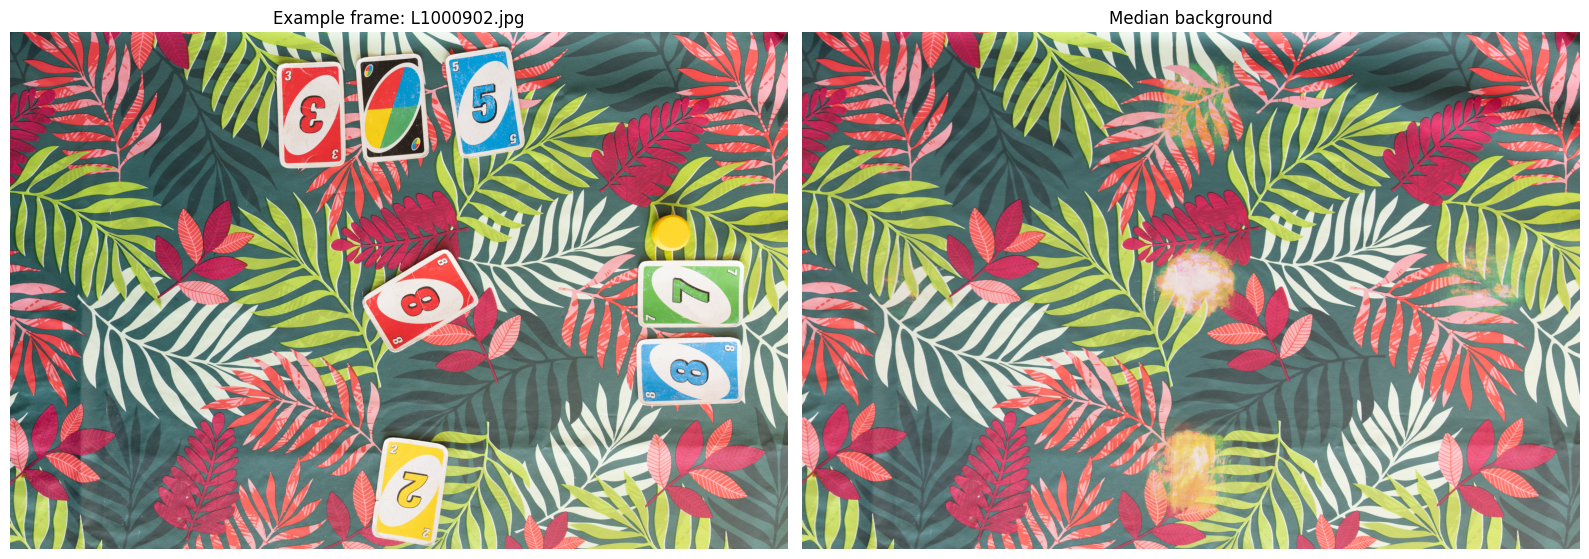

In [7]:
median_rgb = cv2.cvtColor(median_bgr, cv2.COLOR_BGR2RGB)
first_rgb = cv2.cvtColor(stack[0], cv2.COLOR_BGR2RGB)

fig, axes = plt.subplots(1, 2, figsize=(16, 6))

axes[0].imshow(first_rgb)
axes[0].set_title(f"Example frame: {selected_paths[0].name}")
axes[0].axis("off")

axes[1].imshow(median_rgb)
axes[1].set_title("Median background")
axes[1].axis("off")

plt.tight_layout()
plt.show()

In [8]:
OUTPUT_PATH = CHALLENGE_DIR / "median_background.png"
ok = cv2.imwrite(str(OUTPUT_PATH), median_bgr)
if not ok:
    raise RuntimeError(f"Failed to save background to {OUTPUT_PATH}")
print(f"Saved background to: {OUTPUT_PATH}")

Saved background to: C:\Users\UdaRe\OneDrive\Documenti\GitHub\iapr2026do\data\iapr-26-uno-vision-challenge\median_background.png
